# Solution 7: MLP-Only LoRA

Motivated by the "LoRA Without Regret" paper, which claims MLP-only LoRA significantly outperforms attention-only LoRA. I targeted gate_proj, up_proj, down_proj at rank 14 (4.73M params), used a higher learning rate of 5e-4, constant LR schedule, and smaller effective batch size of 8.

It didn't work for this task. Score dropped from 0.79476 (Solution 5) to 0.77464. Attention-only LoRA was still better here.

**Kaggle Score: 0.77464**

## 0. Install Dependencies

In [1]:
!pip install -q "transformers==4.47.0"

!pip uninstall -y torchao 2>/dev/null

!pip install -q accelerate peft bitsandbytes datasets pillow tqdm pandas

import transformers, peft
print(f"transformers: {transformers.__version__}")
print(f"peft: {peft.__version__}")
print("All good. If first run, do Runtime -> Restart session, then run all cells.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 691.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 110.1 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 4.5 MB/s eta 0:00:00
transformers: 4.47.0
peft: 0.19.1
All good. If first run, do Runtime -> Restart session, then run all cells.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Configuration

In [3]:
import transformers
print(f"transformers: {transformers.__version__}")
assert transformers.__version__ >= "4.45.0", f"Too old: {transformers.__version__}"

import os, json, re
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    AutoModelForVision2Seq,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

DATA_DIR = "/content/drive/MyDrive/pixels-to-predictions"
IMG_BASE = os.path.join(DATA_DIR, "images")

OUTPUT_DIR = "/content/smolvlm-lora-v7"
CKPT_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints_v7"
os.makedirs(CKPT_DIR, exist_ok=True)

LORA_RANK = 14
LORA_ALPHA = 28
LORA_DROPOUT = 0.05
LORA_TARGETS = ["gate_proj", "up_proj", "down_proj"]

IMAGE_LONGEST_EDGE = 768

LEARNING_RATE = 5e-4
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 4
NUM_EPOCHS = 3
MAX_SEQ_LEN = 1024
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():


transformers: 4.47.0
Device: cuda


## 2. Load Data

In [4]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

sample_path = os.path.join(IMG_BASE, train_df['image_path'].iloc[0])
assert os.path.exists(sample_path), f"Image not found: {sample_path}"
print(f"Images accessible at {IMG_BASE}")

Train: 3109 | Val: 1048 | Test: 1008
Images accessible at /content/drive/MyDrive/pixels-to-predictions/images


## 3. Load Model & Processor

In [5]:
processor = AutoProcessor.from_pretrained(MODEL_ID)

processor.image_processor.size = {"longest_edge": IMAGE_LONGEST_EDGE}
processor.image_processor.max_image_size = {"longest_edge": IMAGE_LONGEST_EDGE}
processor.image_seq_len = ((IMAGE_LONGEST_EDGE // 16) ** 2) // (4 ** 2)

print(f"Image processor size: {processor.image_processor.size}")
print(f"Max image size (tile): {processor.image_processor.max_image_size}")
print(f"Image seq len: {processor.image_seq_len}")

model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)

print(f"Model type: {type(model).__name__}")

test_img = Image.new('RGB', (768, 768))
test_inputs = processor(text="<image>test", images=[test_img], return_tensors="pt")
print(f"Tiles for 768x768 image: {test_inputs['pixel_values'].shape}")
print(f"Input IDs shape: {test_inputs['input_ids'].shape}")
del test_img, test_inputs

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Image processor size: {'longest_edge': 768}
Max image size (tile): {'longest_edge': 768}
Image seq len: 144


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Model type: Idefics3ForConditionalGeneration
Tiles for 768x768 image: torch.Size([1, 1, 3, 768, 768])
Input IDs shape: torch.Size([1, 148])


## 4. Apply LoRA (MLP-only, text model)

In [6]:
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS,
    task_type=TaskType.CAUSAL_LM,
    bias="none",
)

model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"Total parameters:     {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Trainable %:          {100 * trainable_params / total_params:.2f}%")

assert trainable_params <= 5_000_000, f"OVER BUDGET: {trainable_params:,} > 5,000,000"
print(f"\nUnder 5M cap ({trainable_params:,} <= 5,000,000)")

print(f"\nLoRA targets: {LORA_TARGETS}")
print(f"Rank: {LORA_RANK}, Alpha: {LORA_ALPHA}")
print(f"\nVerifying targeted modules:")
for name, module in model.named_modules():
    if hasattr(module, 'lora_A'):
        print(f"  {name}")

Trainable parameters: 4,730,880 (4.73M)
Total parameters:     512,213,184 (512.2M)
Trainable %:          0.92%

Under 5M cap (4,730,880 <= 5,000,000)

LoRA targets: ['gate_proj', 'up_proj', 'down_proj']
Rank: 14, Alpha: 28

Verifying targeted modules:
  base_model.model.model.text_model.layers.0.mlp.gate_proj
  base_model.model.model.text_model.layers.0.mlp.up_proj
  base_model.model.model.text_model.layers.0.mlp.down_proj
  base_model.model.model.text_model.layers.1.mlp.gate_proj
  base_model.model.model.text_model.layers.1.mlp.up_proj
  base_model.model.model.text_model.layers.1.mlp.down_proj
  base_model.model.model.text_model.layers.2.mlp.gate_proj
  base_model.model.model.text_model.layers.2.mlp.up_proj
  base_model.model.model.text_model.layers.2.mlp.down_proj
  base_model.model.model.text_model.layers.3.mlp.gate_proj
  base_model.model.model.text_model.layers.3.mlp.up_proj
  base_model.model.model.text_model.layers.3.mlp.down_proj
  base_model.model.model.text_model.layers.4.mlp

## 5. Prompt & Dataset (with metadata, no shuffling)

In [7]:
def build_prompt(row, include_answer=False):
    """Build prompt with metadata header. No choice shuffling."""
    choices = json.loads(row['choices'])
    choices_text = "\n".join(f"({i}) {c}" for i, c in enumerate(choices))

    parts = []

    meta_parts = []
    if pd.notna(row.get('subject', None)):
        meta_parts.append(f"Subject: {row['subject']}")
    if pd.notna(row.get('topic', None)):
        meta_parts.append(f"Topic: {row['topic']}")
    if pd.notna(row.get('grade', None)):
        meta_parts.append(f"Grade: {row['grade']}")
    if meta_parts:
        parts.append(" | ".join(meta_parts))

    if pd.notna(row.get('hint', None)) and str(row['hint']).strip():
        parts.append(f"Context: {row['hint'].strip()}")
    if pd.notna(row.get('lecture', None)) and str(row['lecture']).strip():
        parts.append(f"Background: {row['lecture'].strip()}")

    parts.append(f"Question: {row['question'].strip()}")
    parts.append(f"Choices:\n{choices_text}")
    parts.append("Answer with ONLY the number of the correct choice.")

    prompt_text = "\n\n".join(parts)

    if include_answer:
        answer_text = str(int(row['answer']))
        return prompt_text, answer_text
    return prompt_text

sample = train_df.iloc[0]
prompt, answer = build_prompt(sample, include_answer=True)
print("SAMPLE PROMPT (first 400 chars):")
print(prompt[:400])
print(f"\n>>> TARGET ANSWER: {answer}")

SAMPLE PROMPT (first 400 chars):
Subject: natural science | Topic: literacy-in-science | Grade: grade8

Context: Animals often behave in certain ways that can increase their reproductive success. Read the passage about a specific animal behavior. Then, follow the instructions below.

Amazonian poison frogs live in tropical forests in northern South America. After a male and female frog mate, the female frog lays eggs on a plant. 

>>> TARGET ANSWER: 2


In [8]:
class ScienceVQADataset(Dataset):
    def __init__(self, df, img_base, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_base = img_base
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_base, row['image_path'])
        image = Image.open(img_path).convert("RGB")

        if self.is_test:
            prompt_text = build_prompt(row, include_answer=False)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": None, "is_test": True}
        else:
            prompt_text, answer_text = build_prompt(row, include_answer=True)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": answer_text, "is_test": False}

train_dataset = ScienceVQADataset(train_df, IMG_BASE, is_test=False)
val_dataset = ScienceVQADataset(val_df, IMG_BASE, is_test=False)
test_dataset = ScienceVQADataset(test_df, IMG_BASE, is_test=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 3109 | Val: 1048 | Test: 1008


## 6. DataLoaders

In [9]:
from functools import partial

def collate_fn(batch, processor, max_length=MAX_SEQ_LEN):
    """Standard collate — no weighted loss."""
    ids = [item["id"] for item in batch]
    images = [item["image"] for item in batch]
    is_test = batch[0]["is_test"]

    texts = []
    answer_texts = []
    for item in batch:
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": item["prompt_text"]},
        ]}]
        if not is_test:
            messages.append({"role": "assistant", "content": [
                {"type": "text", "text": item["answer_text"]},
            ]})
            answer_texts.append(item["answer_text"])
        text = processor.apply_chat_template(messages, add_generation_prompt=is_test)
        texts.append(text)

    inputs = processor(
        text=texts, images=images, return_tensors="pt",
        padding=True, truncation=True, max_length=max_length,
    )

    if not is_test:
        labels = inputs["input_ids"].clone()
        eos_token_id = processor.tokenizer.eos_token_id

        for i in range(len(batch)):
            labels[i, :] = -100

            eos_positions = (inputs["input_ids"][i] == eos_token_id).nonzero(as_tuple=True)[0]
            if len(eos_positions) < 1:
                continue
            last_eos_pos = eos_positions[-1].item()

            ans_tokens = processor.tokenizer.encode(answer_texts[i], add_special_tokens=False)
            n_ans = len(ans_tokens)
            start = last_eos_pos - n_ans

            labels[i, start:last_eos_pos] = inputs["input_ids"][i, start:last_eos_pos]
            labels[i, last_eos_pos] = eos_token_id

        inputs["labels"] = labels

    inputs["id"] = ids
    return dict(inputs)

collate = partial(collate_fn, processor=processor)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=2, pin_memory=True,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS}")

sample_batch = next(iter(val_loader))
print(f"\ninput_ids: {sample_batch['input_ids'].shape}")
print(f"pixel_values: {sample_batch['pixel_values'].shape}")
for i in range(min(2, len(sample_batch['id']))):
    label_mask = sample_batch['labels'][i] != -100
    label_positions = label_mask.nonzero(as_tuple=True)[0]
    labeled_tokens = sample_batch['labels'][i][label_positions]
    decoded = processor.tokenizer.decode(labeled_tokens)
    print(f"  Sample {i}: '{decoded.strip()}'")

Train batches: 1555 | Val batches: 524
Effective batch size: 8

input_ids: torch.Size([2, 654])
pixel_values: torch.Size([2, 1, 3, 768, 768])
  Sample 0: '0<end_of_utterance>'
  Sample 1: '1<end_of_utterance>'


## 7. Training Loop (constant LR, no warmup)

In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01,
)

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * NUM_EPOCHS
print(f"Total steps: {total_steps}")
print(f"Steps per epoch: {len(train_loader) // GRAD_ACCUM_STEPS}")
print(f"LR: {LEARNING_RATE} (constant, no warmup/cosine)")

Total steps: 1164
Steps per epoch: 388
LR: 0.0005 (constant, no warmup/cosine)


In [11]:
@torch.no_grad()
def evaluate(model, dataloader, processor):
    """Teacher-forced val loss + accuracy."""
    model.eval()
    correct, total, total_loss, num_batches = 0, 0, 0, 0

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        ids = batch.pop("id")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        outputs = model(**batch, labels=labels)
        total_loss += outputs.loss.item()
        num_batches += 1

        logits = outputs.logits
        for i in range(len(ids)):
            label_positions = (labels[i] != -100).nonzero(as_tuple=True)[0]
            if len(label_positions) == 0:
                continue
            ans_pos = label_positions[0].item()
            pred_token = logits[i, ans_pos - 1, :].argmax().item()
            true_token = labels[i, ans_pos].item()
            if pred_token == true_token:
                correct += 1
            total += 1

    model.train()
    return total_loss / max(num_batches, 1), correct / max(total, 1)

print("Pre-training evaluation...")
val_loss, val_acc = evaluate(model, val_loader, processor)
print(f"Pre-training — Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Pre-training evaluation...


Evaluating:   0%|          | 0/524 [00:00<?, ?it/s]

Pre-training — Val Loss: 1.4675 | Val Acc: 0.4485


In [12]:
def save_checkpoint(model, optimizer, scaler, epoch, step,
                    best_val_acc, train_losses, val_losses, val_accs, path):
    model.save_pretrained(os.path.join(path, "lora_adapter"))
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch, "step": step,
        "best_val_acc": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
    }, os.path.join(path, "training_state.pt"))
    print(f"  Checkpoint saved to {path}")

def load_checkpoint(model, optimizer, scaler, path):
    state_path = os.path.join(path, "training_state.pt")
    adapter_path = os.path.join(path, "lora_adapter")
    if not os.path.exists(state_path):
        return 0, 0, 0.0, [], [], []
    state = torch.load(state_path, map_location=device, weights_only=False)
    optimizer.load_state_dict(state["optimizer"])
    scaler.load_state_dict(state["scaler"])
    if os.path.exists(adapter_path):
        model.load_adapter(adapter_path, adapter_name="default")
    print(f"  Resumed from epoch {state['epoch']+1}, best_acc={state['best_val_acc']:.4f}")
    return (state["epoch"], state["step"], state["best_val_acc"],
            state["train_losses"], state["val_losses"], state["val_accs"])

scaler = torch.amp.GradScaler("cuda")

start_epoch, start_step, best_val_acc, train_losses, val_losses, val_accs = \
    load_checkpoint(model, optimizer, scaler, CKPT_DIR)

if start_epoch > 0:
    print(f"Resuming from epoch {start_epoch + 1}")
else:
    best_val_acc = 0.0
    train_losses, val_losses, val_accs = [], [], []
    print("Starting training from scratch")

model.train()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for step, batch in enumerate(pbar):
        if epoch == start_epoch and step < start_step:
            continue

        ids = batch.pop("id")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**batch, labels=labels)
            loss = outputs.loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        if (step + 1) % 200 == 0:
            pbar.set_postfix({"loss": f"{epoch_loss / (step+1):.4f}"})

    start_step = 0

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_loss, val_acc = evaluate(model, val_loader, processor)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val Acc:    {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)
        print(f"  New best! Saved to {OUTPUT_DIR}")

    save_checkpoint(model, optimizer, scaler, epoch, 0,
                    best_val_acc, train_losses, val_losses, val_accs, CKPT_DIR)

print(f"\n{'='*40}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")

Starting training from scratch


Epoch 1/3:   0%|          | 0/1555 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/524 [00:00<?, ?it/s]


Epoch 1/3
  Train Loss: 0.3190
  Val Loss:   0.3073
  Val Acc:    0.7013
  New best! Saved to /content/smolvlm-lora-v7
  Checkpoint saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v7


Epoch 2/3:   0%|          | 0/1555 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/524 [00:00<?, ?it/s]


Epoch 2/3
  Train Loss: 0.2398
  Val Loss:   0.2836
  Val Acc:    0.7481
  New best! Saved to /content/smolvlm-lora-v7
  Checkpoint saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v7


Epoch 3/3:   0%|          | 0/1555 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/524 [00:00<?, ?it/s]


Epoch 3/3
  Train Loss: 0.1949
  Val Loss:   0.3074
  Val Acc:    0.7252
  Checkpoint saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v7

Best Val Accuracy: 0.7481


## 8. Training Curves

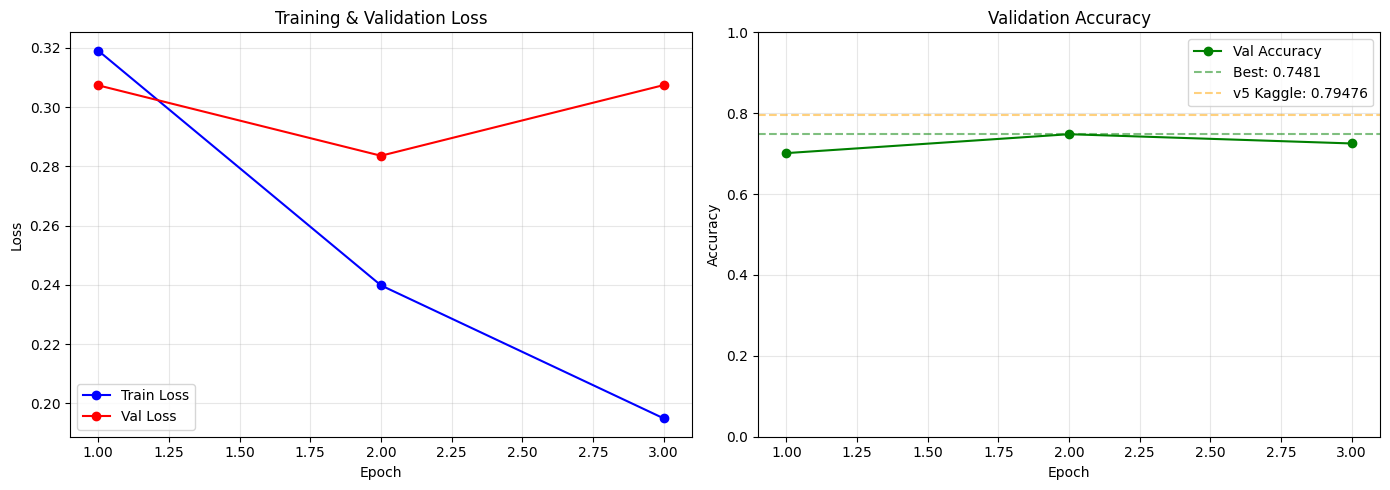

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs, val_losses, 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, val_accs, 'g-o', label='Val Accuracy')
ax2.axhline(y=best_val_acc, color='g', linestyle='--', alpha=0.5, label=f'Best: {best_val_acc:.4f}')
ax2.axhline(y=0.79476, color='orange', linestyle='--', alpha=0.5, label='v5 Kaggle: 0.79476')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 9. Load Best Model for Inference

In [14]:
best_adapter_path = OUTPUT_DIR
if not os.path.exists(os.path.join(OUTPUT_DIR, "adapter_config.json")):
    best_adapter_path = os.path.join(CKPT_DIR, "lora_adapter")
    print(f"Local output missing, loading from Drive: {best_adapter_path}")

base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map="auto")
model = PeftModel.from_pretrained(base_model, best_adapter_path)
model.eval()
print(f"Loaded best model from {best_adapter_path}")

Loaded best model from /content/smolvlm-lora-v7


## 10. Inference - Digit Logit Scoring

In [15]:
DIGIT_TOKEN_IDS = [processor.tokenizer.encode(str(d), add_special_tokens=False)[0] for d in range(10)]
print(f"Digit token IDs: { {d: DIGIT_TOKEN_IDS[d] for d in range(5)} }")

@torch.no_grad()
def predict_digit_logits(model, processor, df, img_base, batch_size=4):
    """Score digit-token logits at the last position."""
    model.eval()
    all_ids, all_preds = [], []

    for start in tqdm(range(0, len(df), batch_size), desc="Predicting"):
        batch_df = df.iloc[start:start + batch_size]
        images, texts, batch_ids, nc_list = [], [], [], []

        for _, row in batch_df.iterrows():
            images.append(Image.open(os.path.join(img_base, row['image_path'])).convert("RGB"))
            prompt = build_prompt(row, include_answer=False)
            messages = [{"role": "user", "content": [
                {"type": "image"}, {"type": "text", "text": prompt}]}]
            texts.append(processor.apply_chat_template(messages, add_generation_prompt=True))
            batch_ids.append(row['id'])
            nc_list.append(row['num_choices'])

        inputs = processor(text=texts, images=images, return_tensors="pt",
                           padding=True, truncation=True, max_length=MAX_SEQ_LEN).to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**inputs)
        logits = outputs.logits

        for i in range(len(batch_df)):
            last_pos = inputs["attention_mask"][i].sum().item() - 1
            next_logits = logits[i, last_pos, :]
            nc = nc_list[i]
            scores = torch.stack([next_logits[DIGIT_TOKEN_IDS[d]] for d in range(nc)])
            all_preds.append(scores.argmax().item())
            all_ids.append(batch_ids[i])

    return all_ids, all_preds

Digit token IDs: {0: 32, 1: 33, 2: 34, 3: 35, 4: 36}


## 11. Val Accuracy (digit logits)

In [16]:
val_ids, val_preds = predict_digit_logits(model, processor, val_df, IMG_BASE, batch_size=4)
val_acc = np.mean([p == a for p, a in zip(val_preds, val_df['answer'].tolist())])
print(f"Val Accuracy (digit logits): {val_acc:.4f}")
print(f"vs v5 (0.7576): {val_acc - 0.7576:+.4f}")
print(f"vs v6 (0.7710): {val_acc - 0.7710:+.4f}")

Predicting:   0%|          | 0/262 [00:00<?, ?it/s]

Val Accuracy (digit logits): 0.7481
vs v5 (0.7576): -0.0095
vs v6 (0.7710): -0.0229


## 12. Generate Test Predictions

In [17]:
print("Generating test predictions...")
test_ids, test_preds = predict_digit_logits(model, processor, test_df, IMG_BASE, batch_size=4)
print(f"Prediction distribution: {pd.Series(test_preds).value_counts().sort_index().to_dict()}")

Generating test predictions...


Predicting:   0%|          | 0/252 [00:00<?, ?it/s]

Prediction distribution: {0: 304, 1: 370, 2: 235, 3: 81, 4: 18}


In [18]:
submission = pd.DataFrame({"id": test_ids, "answer": test_preds})

sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
assert set(submission['id']) == set(sample_sub['id']), "ID mismatch!"
assert len(submission) == len(sample_sub), "Row count mismatch!"

submission = submission.set_index('id').loc[sample_sub['id']].reset_index()
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(f"Shape: {submission.shape}")
print(submission.head(10))
print(f"\nAnswer range: {submission['answer'].min()} to {submission['answer'].max()}")
print(f"Any NaN: {submission['answer'].isna().any()}")

Saved submission.csv
Shape: (1008, 2)
           id  answer
0  test_01750       2
1  test_00128       1
2  test_02891       4
3  test_02425       1
4  test_00930       1
5  test_03725       4
6  test_00009       1
7  test_02880       1
8  test_01208       1
9  test_00619       0

Answer range: 0 to 4
Any NaN: False


## 13. Error Analysis (Val Set)

In [19]:
val_results = val_df.copy()
val_results['predicted'] = val_preds
val_results['correct'] = val_results['predicted'] == val_results['answer']

print(f"Overall Val Accuracy (digit logits): {val_results['correct'].mean():.4f}")

print("\nAccuracy by Subject:")
for subj, group in val_results.groupby('subject'):
    acc = group['correct'].mean()
    print(f"  {subj:20s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by num_choices:")
for nc, group in val_results.groupby('num_choices'):
    acc = group['correct'].mean()
    print(f"  {nc} choices: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by Grade:")
for grade, group in val_results.sort_values('grade').groupby('grade'):
    acc = group['correct'].mean()
    print(f"  {grade:10s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nConfusion Matrix:")
print(pd.crosstab(val_results['answer'], val_results['predicted'],
                  rownames=['Actual'], colnames=['Predicted'], margins=True))

Overall Val Accuracy (digit logits): 0.7481

Accuracy by Subject:
  language science    : 0.5000 (14/28)
  natural science     : 0.7349 (571/777)
  social science      : 0.8189 (199/243)

Accuracy by num_choices:
  2 choices: 0.8484 (207/244)
  3 choices: 0.7224 (367/508)
  4 choices: 0.7857 (198/252)
  5 choices: 0.2727 (12/44)

Accuracy by Grade:
  grade1    : 1.0000 (1/1)
  grade10   : 1.0000 (1/1)
  grade12   : 0.1250 (1/8)
  grade2    : 0.7500 (27/36)
  grade3    : 0.8113 (86/106)
  grade4    : 0.8605 (148/172)
  grade5    : 0.8151 (97/119)
  grade6    : 0.7708 (148/192)
  grade7    : 0.7473 (136/182)
  grade8    : 0.6017 (139/231)

Confusion Matrix:
Predicted    0    1    2   3   4   All
Actual                                
0          245   69   26   7   0   347
1           28  296   33  11   4   372
2           25   27  182   8   5   247
3            6    6    2  56   5    75
4            0    1    0   1   5     7
All        304  399  243  83  19  1048


## 14. Verify Parameter Count

In [20]:
print("=" * 50)
print("PARAMETER BUDGET VERIFICATION")
print("=" * 50)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"Trainable:  {trainable:>12,} ({trainable/1e6:.2f}M)")
print(f"Frozen:     {frozen:>12,} ({frozen/1e6:.1f}M)")
print(f"Total:      {trainable + frozen:>12,} ({(trainable + frozen)/1e6:.1f}M)")
print(f"")
print(f"Budget: {'PASS' if trainable <= 5_000_000 else 'FAIL'} ({trainable:,} {'<=' if trainable <= 5_000_000 else '>'} 5,000,000)")
print(f"")
print(f"Config: r={LORA_RANK}, alpha={LORA_ALPHA}")
print(f"Targets: {LORA_TARGETS}")
print(f"Image size: {IMAGE_LONGEST_EDGE}px")
print(f"LR: {LEARNING_RATE} (constant)")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS}")

PARAMETER BUDGET VERIFICATION
Trainable:             0 (0.00M)
Frozen:      512,213,184 (512.2M)
Total:       512,213,184 (512.2M)

Budget: PASS (0 <= 5,000,000)

Config: r=14, alpha=28
Targets: ['gate_proj', 'up_proj', 'down_proj']
Image size: 768px
LR: 0.0005 (constant)
Effective batch size: 8


## 15. Copy to Drive

In [ ]:
import shutil

drive_submission = os.path.join(CKPT_DIR, "submission.csv")
shutil.copy("submission.csv", drive_submission)
print(f"Copied submission.csv to {drive_submission}")